# Final Project

As in all machine learning problems you should complete the following steps:
1. Load and explore the data (using plots and histograms )
2. Clean/preprocess/transform the data if necessary (first performed on training data and next on test data)
3. Train the machine learning model (in this assignment two models, one linear and one non-linear)
4. Evaluate and optimise the model

However, while performing the steps you should consider our main goals and research questions for doing this project and try to adress them. This can be either in each step or afterwards in discussion and conclusion section (your call!). Below are the research question we are interested in:

* What are the necessary step to clean and prepare the dataset as we have categorial features and missing data.
* What model/classifier provides the best result for this application.
* What is the best choice for our cost function and performance metrics for this problem.

Please also note the following points during the assignment:

* Use functions from open source libraries like sci-kit learn and keras and avoid using your own hand-written functions from previous assignments. You can also use our [cheatsheet](https://colab.research.google.com/drive/12h-QBlsaWXkjGIRoJXfF4yqi1elnX9qn?usp=sharing).
* Feel free to contact us on Teams if you need more description.
* This notebook is structured like a scientific paper. The text should provide a high-level overview of your approach. Please don't include any details about your code in the text but add them as comments in the code itself. Your code should be cleane and readable with enough comments.
* There are some instructions and questions in each section, remove the highlighted text in blue and replace it with your explanations and answers.

You can delete this section before submission.

## 1. Introduction


<font color=#6698FF> Tycho Brouwer, score and Leaderboard rank here.


## 2. Data


In [1]:
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import balanced_accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, Perceptron
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR, NuSVR
from sklearn.preprocessing import StandardScaler
import seaborn as sns
%matplotlib inline 

### 2.1 Dataset
<font color=#6698FF>In this section, we load and explore the dataset.

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

###### 2.1.1 Train-test split
<font color=#6698FF>In the below, we split the train data into a test and a train set. Set a value for the `test_size` yourself. Argue why the test value can not be too small or too large. You can also use k-fold cross validation.


In [3]:
train = pd.read_csv('../input/LANL-Earthquake-Prediction/train.csv', 
                    dtype={'acoustic_data': np.int16, 'time_to_failure':np.float64})

data_train, data_test = train_test_split(train, test_size=0.3, shuffle=False)

usually the data is split into 70% for the training and 30% for validation. this is in order to train the model good but also being able to test it and validate that it is indeed a good model. 

In [4]:
train.shape

(629145480, 2)

### 2.2 Data Exploration

<font color=#6698FF> Explore the features and target variables of the dataset. Think about making some scatter plots, box plots, histograms or printing the data, but feel free to choose any method that suits you.
What do you think is the right performance
metric to use for this dataset? Clearly explain which performance metric you
choose and why.
Algorithmic bias can be a real problem in Machine Learning.  Explain what you believe.</font>

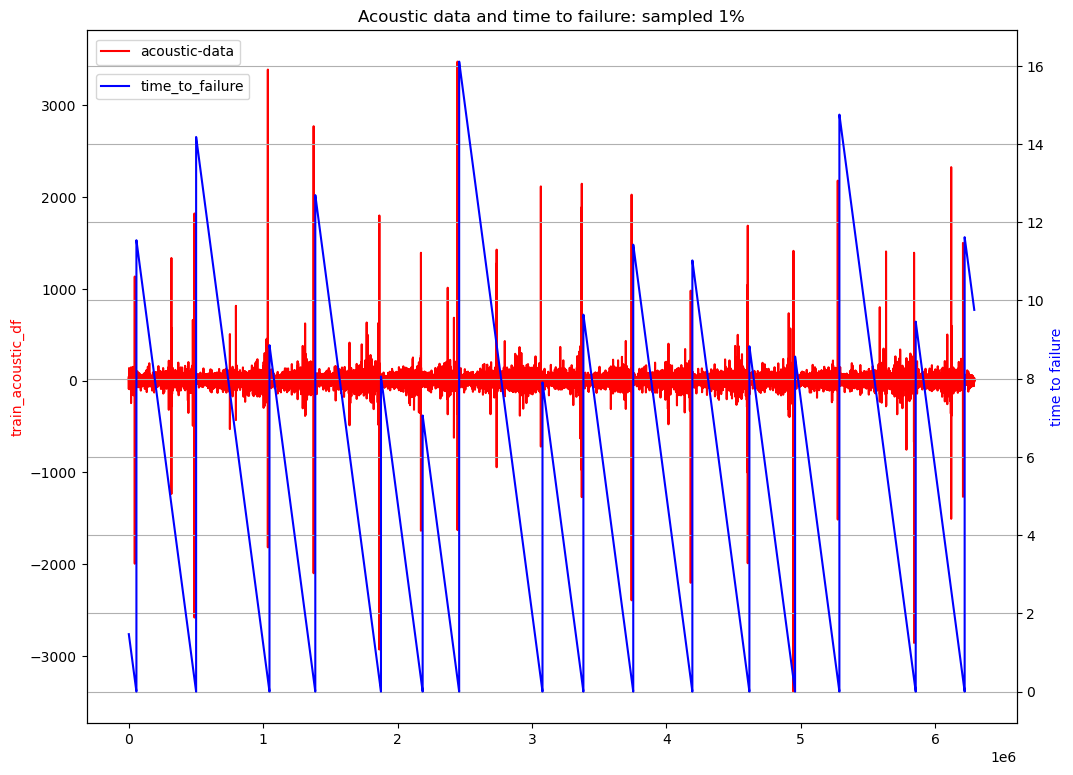

In [5]:
train_acoustic_df = train['acoustic_data'].values[::100]
train_acoustic_df.shape

train_time_to_failure_df = train['time_to_failure'].values[::100]



def plot_acc_ttf_data(train_acoustic_df,train_time_to_failure_df,title='Acoustic data and time to failure: sampled 1%'):
    fig ,ax1 = plt.subplots(figsize=(12,9))
    plt.title(title)
    plt.plot(train_acoustic_df,color='r')
    ax1.set_ylabel('train_acoustic_df',color='r')
    plt.legend(['acoustic-data'],loc=(0.01,0.95))
    ax2 = ax1.twinx()
    plt.plot(train_time_to_failure_df,color='b')
    ax2.set_ylabel('time to failure',color='b')
    plt.legend(['time_to_failure'],loc=(0.01,0.9))
    plt.grid(True)
    
plot_acc_ttf_data(train_acoustic_df,train_time_to_failure_df)

the peak in the acoustic data results in a jump in the time to failure

In [6]:
del train_time_to_failure_df
del train_acoustic_df

In [7]:
train_acoustic_df = train['acoustic_data'].values[:6291455]
train_time_to_failure_df = train['time_to_failure'].values[:6291455]

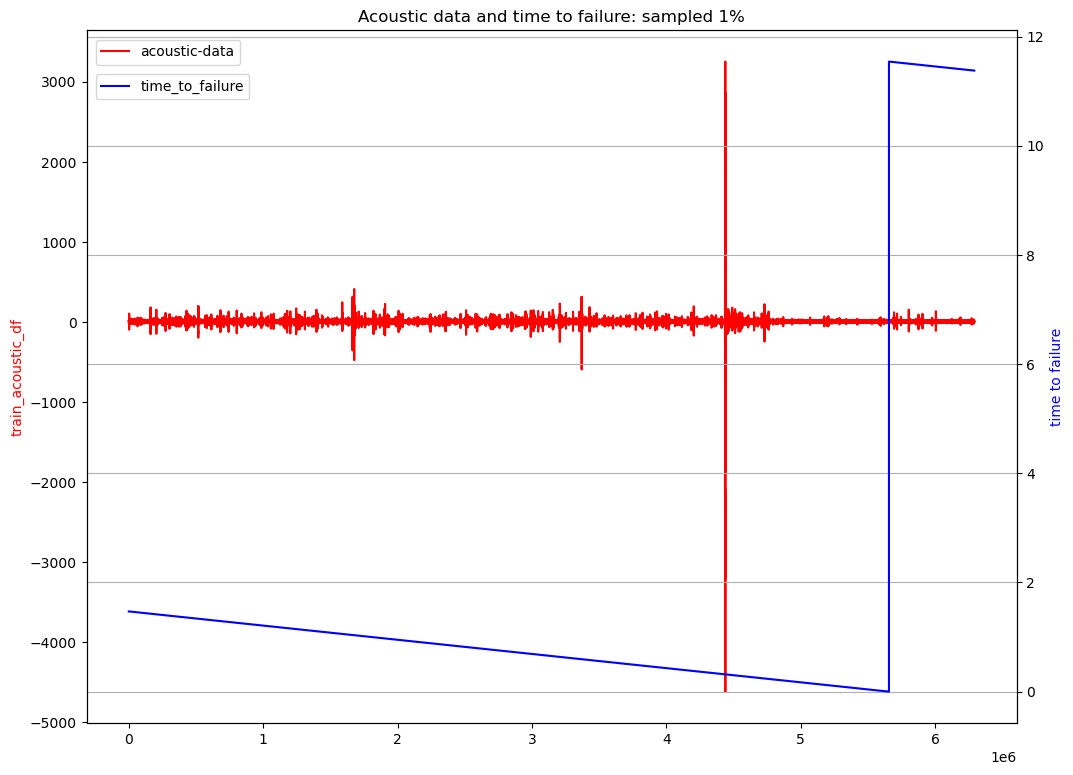

In [8]:
plot_acc_ttf_data(train_acoustic_df,train_time_to_failure_df)

the time to failure is just after the acoustic data is measured 

### 2.3 Data Preparation

<font color=#6698FF>  This dataset hasn’t been cleaned yet. Meaning that some attributes (features) are in numerical format and some are in categorial format. Moreover, there are missing values as well. However, all Scikit-learn’s implementations of these algorithms expect numerical features. Check for all features if they are in categorial and use a method to transform them to numerical values. For the numerical data, handle the missing data and normalize the data. 
Note that you are only allowed to use training data for preprocessing but you then need to perform similar changes on test data too.
You can use [pipelining](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) to help with the preprocessing.</font>

In [9]:
rows = 150_000
segments = int(np.floor(data_train.shape[0] / rows))

In [10]:
def extract_features_from_segment(segment, seg, X):
    x = pd.Series(seg['acoustic_data'].values)

    X.loc[segment, 'mean'] = x.mean()
    X.loc[segment, 'std'] = x.std()
    X.loc[segment, 'max'] = x.max()
    X.loc[segment, 'min'] = x.min()
    X.loc[segment, 'kurt'] = x.kurtosis()
    X.loc[segment, 'skew'] = x.skew()
    
#Rolling window of size 100
    x_roll_std = x.rolling(window = 100).std().dropna().values
    x_roll_mean = x.rolling(window= 100).mean().dropna().values
    
    #Features from rolling mean
    X.loc[segment, 'rolling_mean'] =x_roll_mean.mean()
    X.loc[segment, 'rolling_mean'] =x_roll_mean.std()
    
    #Features from rolling std
    X.loc[segment, 'rolling_std'] = x_roll_std.mean()
    X.loc[segment, 'rolling_std'] = x_roll_std.std()

In [11]:
X_train = pd.DataFrame(index=range(segments), dtype=np.float64)
y_train = pd.DataFrame(index=range(segments), dtype=np.float64, columns=['time_to_failure'])
for segment in range(segments):
    seg = data_train.iloc[segment*rows:segment*rows+rows]
    extract_features_from_segment(segment, seg, X_train)
    y_train.loc[segment, 'time_to_failure'] = seg['time_to_failure'].values[-1]

In [12]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)


test_segments = int(np.floor(data_test.shape[0] / rows))
X_test = pd.DataFrame(index=range(test_segments), dtype=np.float64)
y_test = pd.DataFrame(index=range(test_segments), dtype=np.float64, columns=['time_to_failure'])
for segment in range(test_segments):
    seg = data_test.iloc[segment*rows:segment*rows+rows]
    extract_features_from_segment(segment, seg, X_test)
    y_test.loc[segment, 'time_to_failure'] = seg['time_to_failure'].values[-1]
new_scaler = StandardScaler()
new_scaler.fit(X_test)
X_test_scaled = new_scaler.transform(X_test)


## 3. Training and Results
<font color=#6698FF> Briefly introduce algorithms you choose. 
Present your balanced accuracies for both test and training data for all classifiers. Analyse the performance on test and training in terms of bias and variance. Give one advantage and one drawback of the method you use.


score of the linearRegression model: 0.27393587483496584
lineaRegression moddel train mse: 9.934450257985553
lineaRegression moddel train mae: 2.477550491024164
score of the linearRegression model: 0.17187013696293318
lineaRegression moddel test mse: 10.698921883769097
lineaRegression moddel test mae: 2.5101632910819593


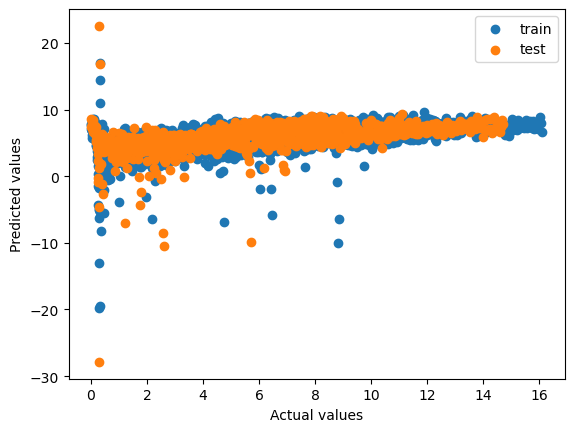

In [13]:
# define the model
model = LinearRegression()
# fit the model
model.fit(X_train_scaled, y_train.values.flatten())
# predict
pred=model.predict(X_train_scaled)
score = model.score(X_train_scaled, y_train)
mae = mean_absolute_error(y_train.values.flatten(), pred)
mse = mean_squared_error(y_train.values.flatten(), pred)
print('score of the linearRegression model: ' + str(score))
print('lineaRegression moddel train mse: ' + str(mse))
print('lineaRegression moddel train mae: ' + str(mae))


plt.scatter(y_train.values.flatten(), pred, label = 'train')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()

# define the model
model = LinearRegression()
# fit the model
model.fit(X_train_scaled, y_train.values.flatten())
# predict
pred=model.predict(X_test_scaled)
score = model.score(X_test_scaled, y_test)
mae = mean_absolute_error(y_test.values.flatten(), pred)
mse = mean_squared_error(y_test.values.flatten(), pred)
print('score of the linearRegression model: ' + str(score))
print('lineaRegression moddel test mse: ' + str(mse))
print('lineaRegression moddel test mae: ' + str(mae))

plt.scatter(y_test.values.flatten(), pred, label = 'test')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()

regression forest train mae:  0.8289160564456319
regression forest train mse: 1.140323274252636
 score regression forest: 0.9166589193136235
regression forest test mae:  0.7656385591778507
regression forest test mse: 1.0695230403469511
 score regression forest: 0.9172155869030904


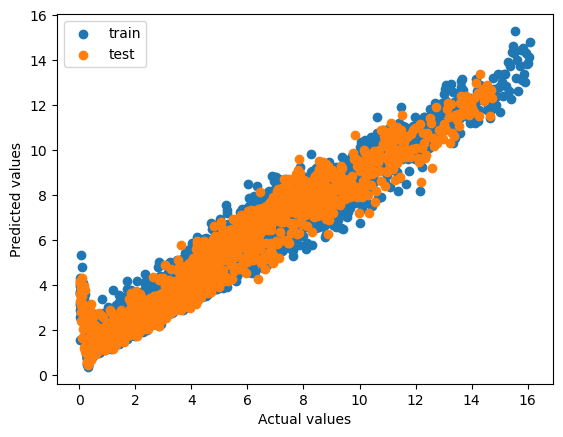

In [14]:

model = RandomForestRegressor()
model.fit(X_train_scaled, y_train.values.flatten())
pred = model.predict(X_train_scaled)
MAE = mean_absolute_error(y_train.values.flatten(), pred)
MSE = mean_squared_error(y_train.values.flatten(), pred)
score = model.score(X_train_scaled, y_train)
print('regression forest train mae: ', MAE)
print('regression forest train mse:', MSE)
print(' score regression forest:', score )
plt.scatter(y_train.values.flatten(), pred, label='train')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()
    


model = RandomForestRegressor()
model.fit(X_test_scaled, y_test.values.flatten())
pred = model.predict(X_test_scaled)
MAE = mean_absolute_error(y_test.values.flatten(), pred)
MSE = mean_squared_error(y_test.values.flatten(), pred)
score = model.score(X_test_scaled, y_test)
print('regression forest test mae: ', MAE)
print('regression forest test mse:', MSE)
print(' score regression forest:', score )
plt.scatter(y_test.values.flatten(), pred, label='test')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()

## 4. Discussion and Conclusion

<font color=#6698FF>Discuss all the choices you made during the process and your final conclusions.  Highlight the strong points of your approach, discuss its shortcomings  and suggest some future approaches that may improve it. Please be self critical here. The assignment is not about achieving a state of the art performance, but about showing what you have learned the concepts during the course.</font>

there was a lot of data available to use so first I had to devide them into segments inorder to have smaller sets of data. Than the features were extracted for each segment. As last the models were made with a linear one and a non linear, randomforestregressor. The mse of the linear model is suprisingly high in comparison with the non linear one, the mae is hover a bit lower. The last noticeable outcome is the score of the linear model, this is really low. So overall the non linear model is in this case way better. 

## 5. References

notebooks:
https://www.kaggle.com/code/gpreda/lanl-earthquake-eda-and-prediction/notebook

https://www.kaggle.com/code/inversion/basic-feature-benchmark

https://www.kaggle.com/code/jessteijn/ml23-week8

https://www.kaggle.com/code/dineshm2/lanl-earthquake-prediction


In [15]:
submission = pd.read_csv('/kaggle/input/LANL-Earthquake-Prediction/sample_submission.csv', index_col='seg_id')
X_test = pd.DataFrame(columns=X_train.columns, dtype=np.float64, index=submission.index)
for seg_id in X_test.index:
    seg = pd.read_csv('/kaggle/input/LANL-Earthquake-Prediction/test/' + seg_id + '.csv')
    extract_features_from_segment(seg_id, seg, X_test)
    
X_test_scaled = scaler.transform(X_test)
submission['time_to_failure'] = model.predict(X_test_scaled)
submission.to_csv('submission.csv')